In [0]:
import os

# Check current directory and list uploaded files
current_dir = os.getcwd()
print(f"Current Working Directory: {current_dir}")
print("Files detected:")
for f in os.listdir(current_dir):
    print(f" - {f}")

Current Working Directory: /Workspace/Users/sanketgharat234@gmail.com/macro-analytics-cluster
Files detected:
 - rbi.xlsx
 - nifty50.csv
 - Notebook.ipynb


In [0]:
%pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import os
import pandas as pd
from pyspark.sql import functions as F

# Identify paths directly in your workspace
current_dir = os.getcwd()
nifty_file = os.path.join(current_dir, "nifty50.csv")
rbi_file = os.path.join(current_dir, "rbi.xlsx")

# 1. Load Nifty 50 CSV into PySpark
nifty_raw_df = (
    spark.read.format("csv")
    .option("header", "true")
    .option("inferSchema", "true")
    .load(f"file:{nifty_file}")
)

print("--- NIFTY 50 COLUMNS ---")
nifty_raw_df.printSchema()

# 2. Load Excel sheet 'selected' from rbi.xlsx
rbi_pandas = pd.read_excel(rbi_file, sheet_name="selected")
rbi_pandas.columns = [str(c).strip() for c in rbi_pandas.columns]

# Convert to Spark DataFrame
rbi_raw_df = spark.createDataFrame(rbi_pandas)

print("--- RBI COLUMNS ---")
rbi_raw_df.printSchema()

--- NIFTY 50 COLUMNS ---
root
 |-- Date : string (nullable = true)
 |-- Open : double (nullable = true)
 |-- High : double (nullable = true)
 |-- Low : double (nullable = true)
 |-- Close : double (nullable = true)
 |-- Shares Traded : integer (nullable = true)
 |-- Turnover (₹ Cr): double (nullable = true)

--- RBI COLUMNS ---
root
 |-- Items: string (nullable = true)
 |-- Broad Money: double (nullable = true)
 |-- Bank Credit: double (nullable = true)
 |-- Total (FDI+FII) i.e NET Flows: double (nullable = true)
 |-- Total Foreign Exchange Reserves: double (nullable = true)
 |-- Trade Balance: double (nullable = true)



In [0]:
import numpy as np
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType

# 1. Clean whitespace from Nifty column headers
clean_nifty_cols = [c.strip() for c in nifty_raw_df.columns]
nifty_df = nifty_raw_df.toDF(*clean_nifty_cols)

# 2. Parse Date safely using try_to_date across all common NSE date patterns
# '04-OCT-2022' matches 'dd-MMM-yyyy' (case-insensitive in Spark SQL patterns)
nifty_cleaned = nifty_df.withColumn(
    "Parsed_Date",
    F.coalesce(
        F.expr("try_to_date(`Date`, 'dd-MMM-yyyy')"),
        F.expr("try_to_date(`Date`, 'yyyy-MM-dd')"),
        F.expr("try_to_date(`Date`, 'dd-MM-yyyy')"),
        F.expr("try_to_date(`Date`)")
    )
).filter(F.col("Parsed_Date").isNotNull())

# Extract Year-Month string
nifty_cleaned = nifty_cleaned.withColumn(
    "Year_Month", F.date_format(F.col("Parsed_Date"), "yyyy-MM")
)

# 3. Calculate Daily Log Returns: ln(Close_t / Close_{t-1})
date_window = Window.orderBy("Parsed_Date")

nifty_returns = nifty_cleaned.withColumn(
    "Prev_Close", F.lag("Close", 1).over(date_window)
).withColumn(
    "Daily_Log_Return", F.log(F.col("Close") / F.col("Prev_Close"))
)

# 4. Aggregate to Monthly Silver Layer
monthly_window = Window.partitionBy("Year_Month").orderBy(F.desc("Parsed_Date"))

turnover_col = [c for c in nifty_cleaned.columns if "Turnover" in c][0]
shares_col = [c for c in nifty_cleaned.columns if "Shares" in c][0]

nifty_monthly_silver = (
    nifty_returns
    .withColumn("Rank_In_Month", F.row_number().over(monthly_window))
    .groupBy("Year_Month")
    .agg(
        # Last trading day close of each month
        F.first(F.when(F.col("Rank_In_Month") == 1, F.col("Close")), ignorenulls=True).alias("Nifty_Close"),
        # Total monthly turnover and shares
        F.sum(turnover_col).alias("Turnover_Cr"),
        F.sum(shares_col).alias("Shares_Traded"),
        # Annualized Realized Volatility: StdDev of daily log returns * sqrt(252)
        (F.stddev("Daily_Log_Return") * F.lit(np.sqrt(252))).alias("Realized_Vol_Annualized"),
        F.count("Parsed_Date").alias("Trading_Days")
    )
)

# 5. Month-over-Month Nifty Return
ym_window = Window.orderBy("Year_Month")
nifty_monthly_silver = nifty_monthly_silver.withColumn(
    "Prev_Month_Close", F.lag("Nifty_Close", 1).over(ym_window)
).withColumn(
    "Nifty_MoM_Return", F.log(F.col("Nifty_Close") / F.col("Prev_Month_Close"))
).filter(F.col("Nifty_MoM_Return").isNotNull())

# Verification
print(f"Total Monthly Records: {nifty_monthly_silver.count()}")
nifty_monthly_silver.orderBy("Year_Month").show(5)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1155: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Total Monthly Records: 48
+----------+-----------+------------------+-------------+-----------------------+------------+----------------+--------------------+
|Year_Month|Nifty_Close|       Turnover_Cr|Shares_Traded|Realized_Vol_Annualized|Trading_Days|Prev_Month_Close|    Nifty_MoM_Return|
+----------+-----------+------------------+-------------+-----------------------+------------+----------------+--------------------+
|   2021-11|    16983.2|484381.68000000005|   5853408560|    0.16200332612725074|          20|        17671.65|-0.03973704044424...|
|   2021-12|   17354.05|445748.48000000004|   5499273903|    0.16970827655175083|          23|         16983.2| 0.02160128841162364|
|   2022-01|   17339.85|489373.79000000004|   5435447093|    0.16913648851910273|          20|        17354.05|-8.18587751330096...|
|   2022-02|    16793.9| 468244.3299999999|   5620292631|    0.28489752025021936|          20|        17339.85|-0.03199159555986745|
|   2022-03|   17464.75|         601435.77|

Clean and Standardize the RBI Dataset

In [0]:
rbi_raw_df.select("Items").show(5, truncate=False)

+--------+
|Items   |
+--------+
|Sep-2026|
|Aug-2026|
|Jul-2026|
|Jun-2026|
|May-2026|
+--------+
only showing top 5 rows


In [0]:
import os
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

current_dir = os.getcwd()
rbi_file = os.path.join(current_dir, "rbi.xlsx")

# 1. Read Excel directly and rename columns immediately to remove spaces, dots, and brackets
rbi_pandas = pd.read_excel(rbi_file, sheet_name="selected")

# Map original Excel columns to clean alphanumeric names
rbi_pandas = rbi_pandas.rename(columns={
    "Items": "Items",
    "Broad Money": "M3_Supply",
    "Bank Credit": "Bank_Credit",
    "Total (FDI+FII) i.e NET Flows": "Net_Capital_Flows",
    "Total Foreign Exchange Reserves": "Forex_Reserves",
    "Trade Balance": "Trade_Balance"
})

# 2. Create Spark DataFrame with already-clean names
rbi_clean_raw = spark.createDataFrame(rbi_pandas)

# 3. Parse 'MMM-yyyy' date into 'yyyy-MM'
rbi_silver = (
    rbi_clean_raw
    .withColumn(
        "Parsed_Date",
        F.expr("try_to_date(Items, 'MMM-yyyy')")
    )
    .withColumn(
        "Year_Month",
        F.date_format(F.col("Parsed_Date"), "yyyy-MM")
    )
    .filter(F.col("Year_Month").isNotNull())
    .select(
        F.col("Year_Month"),
        F.col("M3_Supply").cast(DoubleType()),
        F.col("Bank_Credit").cast(DoubleType()),
        F.col("Net_Capital_Flows").cast(DoubleType()),
        F.col("Forex_Reserves").cast(DoubleType()),
        F.col("Trade_Balance").cast(DoubleType())
    )
)

print(f"Total Cleaned RBI Records: {rbi_silver.count()}")
rbi_silver.orderBy(F.desc("Year_Month")).show(5)

Total Cleaned RBI Records: 309
+----------+---------------+-------------+-----------------+--------------+-------------+
|Year_Month|      M3_Supply|  Bank_Credit|Net_Capital_Flows|Forex_Reserves|Trade_Balance|
+----------+---------------+-------------+-----------------+--------------+-------------+
|   2026-09|           NULL|2.232925841E7|             NULL|   7342984.532|         NULL|
|   2026-08|3.32216902782E7|2.238715247E7|             NULL|    7066658.36|         NULL|
|   2026-07|3.22778134282E7|2.207840337E7| 109771.151525051|   6612148.358|   -306433.57|
|   2026-06|3.18933201683E7|2.193039821E7| 41652.9851243638|    6294506.77| -289070.6307|
|   2026-05|3.13620499133E7|2.151540248E7|-58411.1983062149|    6483678.12| -267289.4122|
+----------+---------------+-------------+-----------------+--------------+-------------+
only showing top 5 rows


join 

Inner join nifty_monthly_silver and rbi_silver on Year_Month.



In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Inner Join on Year_Month
joined_panel = nifty_monthly_silver.join(
    rbi_silver,
    on="Year_Month",
    how="inner"
).orderBy("Year_Month")

# 2. Filter out incomplete reporting rows (where core macro releases are NULL)
complete_panel = joined_panel.filter(
    F.col("M3_Supply").isNotNull() &
    F.col("Bank_Credit").isNotNull() &
    F.col("Net_Capital_Flows").isNotNull() &
    F.col("Forex_Reserves").isNotNull() &
    F.col("Trade_Balance").isNotNull()
)

# 3. Feature Engineering: Macro MoM Growth Rates & Lag Transmission
panel_window = Window.orderBy("Year_Month")

gold_features = (
    complete_panel
    # Money supply and credit MoM growth rates
    .withColumn(
        "M3_MoM_Growth",
        (F.col("M3_Supply") - F.lag("M3_Supply", 1).over(panel_window)) / F.lag("M3_Supply", 1).over(panel_window)
    )
    .withColumn(
        "Credit_MoM_Growth",
        (F.col("Bank_Credit") - F.lag("Bank_Credit", 1).over(panel_window)) / F.lag("Bank_Credit", 1).over(panel_window)
    )
    .withColumn(
        "Forex_MoM_Growth",
        (F.col("Forex_Reserves") - F.lag("Forex_Reserves", 1).over(panel_window)) / F.lag("Forex_Reserves", 1).over(panel_window)
    )
    # 1-Month Lagged foreign capital flows (assessing leading transmission impact)
    .withColumn("Lag1_Net_Capital_Flows", F.lag("Net_Capital_Flows", 1).over(panel_window))
    .withColumn("Lag1_Credit_MoM_Growth", F.lag("Credit_MoM_Growth", 1).over(panel_window))
    # Market Stress Regime Flag (Target for Deals Diligence)
    .withColumn(
        "Stress_Regime",
        F.when(
            (F.col("Realized_Vol_Annualized") > 0.18) | (F.col("Nifty_MoM_Return") < -0.04),
            1
        ).otherwise(0)
    )
    # Drop the first observation where lag calculation produces nulls
    .filter(F.col("M3_MoM_Growth").isNotNull())
)

# 4. Save as a Delta Lake Table
gold_features.write.format("delta").mode("overwrite").saveAsTable("macro_valuation_stress_gold")

print(f"Total Gold Panel Rows: {spark.table('macro_valuation_stress_gold').count()}")
display(spark.table("macro_valuation_stress_gold").select(
    "Year_Month",
    "Nifty_Close",
    "Nifty_MoM_Return",
    "Realized_Vol_Annualized",
    "M3_MoM_Growth",
    "Credit_MoM_Growth",
    "Net_Capital_Flows",
    "Stress_Regime"
).orderBy(F.desc("Year_Month")))

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1155: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Total Gold Panel Rows: 45


Year_Month,Nifty_Close,Nifty_MoM_Return,Realized_Vol_Annualized,M3_MoM_Growth,Credit_MoM_Growth,Net_Capital_Flows,Stress_Regime
2026-07,24383.6,0.02146639843054835,0.11794684685024803,0.012055604680573916,0.006748858756815075,109771.151525051,0
2026-06,23865.75,0.013414102242879367,0.11528297957667594,0.016939908471183773,0.01928830893987536,41652.9851243638,0
2026-05,23547.75,-0.01892146730697169,0.1379362197390852,0.006355819858038879,0.014365610794837612,-58411.1983062149,0
2026-04,23997.55,0.07195798199223008,0.18805601480164266,-0.009192998199479285,-0.006985013544788993,-16471.0304951357,1
2026-03,22331.4,-0.12000265338804761,0.2568776873261631,0.0381137093808735,0.02933273072229469,-130031.243090099,1
2026-02,25178.65,-0.0056238551529020865,0.16080808611773872,0.013202593833579796,0.013478278504866175,59179.2109919459,0
2026-01,25320.65,-0.03144850298786792,0.09212170518260446,0.0035235053901847176,0.007600536105598005,-14274.9843678035,0
2025-12,26129.6,-0.0028032285081682996,0.0748544064041226,0.022714667266414953,0.04052057532941444,-57066.4289343253,0
2025-11,26202.95,0.018521455289600006,0.07594745120392225,0.004800652747656463,0.007001670261711841,-1130.53331297972,0
2025-10,25722.1,0.04415298387730961,0.07843376512351195,0.022829591539325907,0.025964040431230594,10194.2228799262,0


In [0]:
import os

# 1. Convert the Gold Spark table to a Pandas DataFrame
gold_df = spark.table("macro_valuation_stress_gold").toPandas()

# Sort chronologically
gold_df = gold_df.sort_values(by="Year_Month", ascending=True)

# 2. Define output CSV path in your current working directory
current_dir = os.getcwd()
output_csv_path = os.path.join(current_dir, "macro_valuation_stress_gold.csv")

# 3. Export to CSV
gold_df.to_csv(output_csv_path, index=False)

print(f"File successfully exported to: {output_csv_path}")
print(f"Shape: {gold_df.shape[0]} rows, {gold_df.shape[1]} columns")

File successfully exported to: /Workspace/Users/sanketgharat234@gmail.com/macro-analytics-cluster/macro_valuation_stress_gold.csv
Shape: 45 rows, 19 columns


In [0]:
import os
import pandas as pd

print(f"Total Columns: {len(gold_df.columns)}\n")
for idx, col in enumerate(gold_df.columns, 1):
    print(f"{idx:2d}. {col}")

Total Columns: 19

 1. Year_Month
 2. Nifty_Close
 3. Turnover_Cr
 4. Shares_Traded
 5. Realized_Vol_Annualized
 6. Trading_Days
 7. Prev_Month_Close
 8. Nifty_MoM_Return
 9. M3_Supply
10. Bank_Credit
11. Net_Capital_Flows
12. Forex_Reserves
13. Trade_Balance
14. M3_MoM_Growth
15. Credit_MoM_Growth
16. Forex_MoM_Growth
17. Lag1_Net_Capital_Flows
18. Lag1_Credit_MoM_Growth
19. Stress_Regime


EDA

In [0]:
%pip install seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


                     DESCRIPTIVE STATISTICS SUMMARY (N=45)                      


Obs,Mean,StdDev,Min,Median,Max
45.0,21060.5756,3440.0432,15780.25,19753.8,26202.95
45.0,0.008,0.0498,-0.12,0.0032,0.2194
45.0,0.1464,0.1269,0.0094,0.1179,0.8964
45.0,533449.4916,125694.9588,47477.05,543458.32,802506.57
45.0,0.0112,0.0174,-0.0092,0.0087,0.1074
45.0,0.0154,0.0186,-0.0098,0.0135,0.1151
45.0,0.0078,0.0336,-0.0343,0.0055,0.1801
45.0,3947.0078,42463.308,-130031.2431,10194.2229,109771.1515
45.0,-203998.7564,57716.3486,-376508.2927,-194466.9984,-118377.0221



Stress Regime Distribution: Normal = 77.8%, Stressed = 22.2%



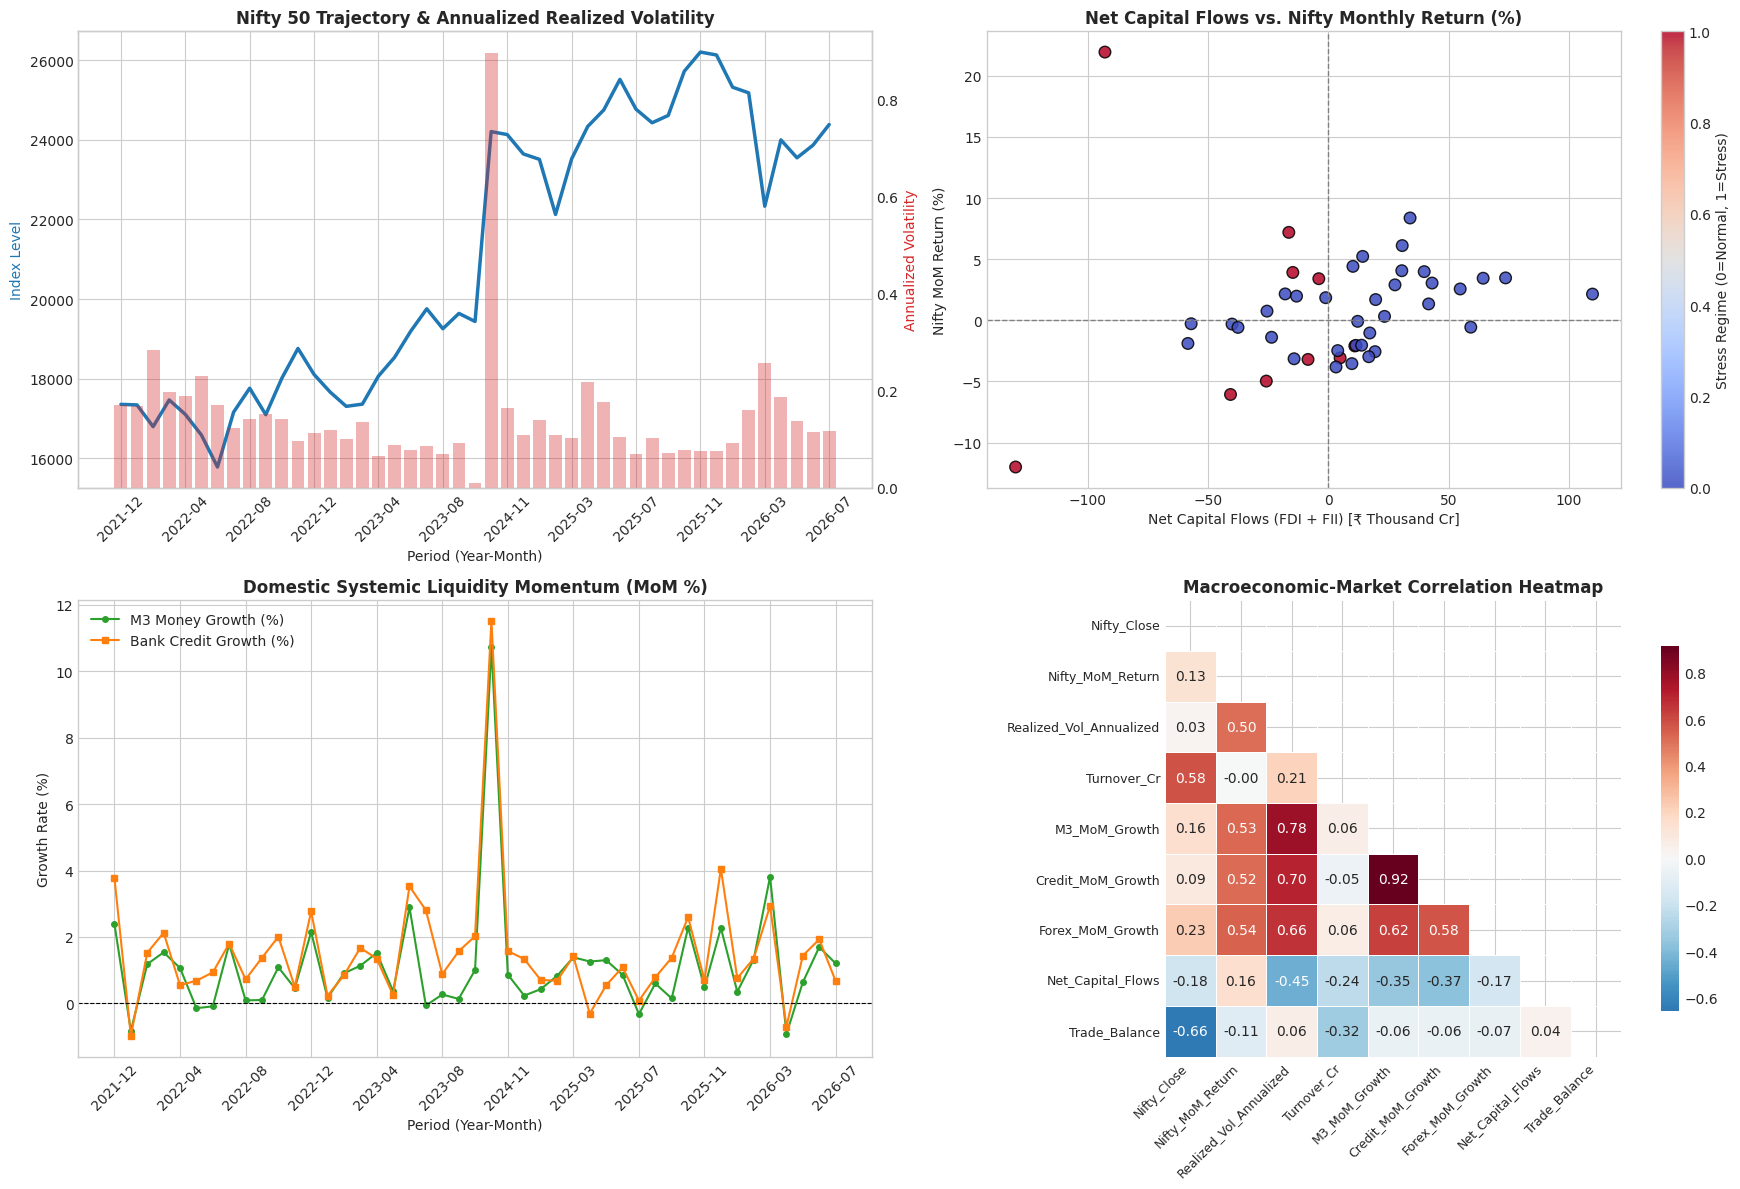

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load Gold Table into Pandas for Exploratory Analysis
eda_df = spark.table("macro_valuation_stress_gold").toPandas()
eda_df["Year_Month"] = eda_df["Year_Month"].astype(str)
eda_df = eda_df.sort_values("Year_Month").reset_index(drop=True)

# 2. Descriptive Statistics Summary Table
analysis_cols = [
    "Nifty_Close",
    "Nifty_MoM_Return",
    "Realized_Vol_Annualized",
    "Turnover_Cr",
    "M3_MoM_Growth",
    "Credit_MoM_Growth",
    "Forex_MoM_Growth",
    "Net_Capital_Flows",
    "Trade_Balance"
]

print("================================================================================")
print("                     DESCRIPTIVE STATISTICS SUMMARY (N=45)                      ")
print("================================================================================")
summary_stats = eda_df[analysis_cols].describe().T[["count", "mean", "std", "min", "50%", "max"]]
summary_stats.columns = ["Obs", "Mean", "StdDev", "Min", "Median", "Max"]
display(summary_stats.round(4))

# 3. Stress Regime Distribution
stress_counts = eda_df["Stress_Regime"].value_counts(normalize=True) * 100
print(f"\nStress Regime Distribution: Normal = {stress_counts.get(0, 0):.1f}%, Stressed = {stress_counts.get(1, 0):.1f}%\n")

# 4. Multi-Panel Visualizations
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Subplot A: Nifty Index vs Realized Volatility
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
ax1.plot(eda_df["Year_Month"], eda_df["Nifty_Close"], color="#1f77b4", linewidth=2.5, label="Nifty 50 Close")
ax1_twin.bar(eda_df["Year_Month"], eda_df["Realized_Vol_Annualized"], alpha=0.35, color="#d62728", label="Annualized Volatility")
ax1.set_title("Nifty 50 Trajectory & Annualized Realized Volatility", fontsize=12, fontweight="bold")
ax1.set_xlabel("Period (Year-Month)")
ax1.set_ylabel("Index Level", color="#1f77b4")
ax1_twin.set_ylabel("Annualized Volatility", color="#d62728")
ax1.set_xticks(range(0, len(eda_df), 4))
ax1.set_xticklabels(eda_df["Year_Month"].iloc[::4], rotation=45)
ax1_twin.grid(False)

# Subplot B: Net Capital Flows vs Monthly Returns
ax2 = axes[0, 1]
norm_flows = eda_df["Net_Capital_Flows"] / 1000  # Convert to thousands for cleaner display
scatter = ax2.scatter(
    norm_flows, 
    eda_df["Nifty_MoM_Return"] * 100, 
    c=eda_df["Stress_Regime"], 
    cmap="coolwarm", 
    s=70, 
    edgecolors="black", 
    alpha=0.85
)
ax2.axhline(0, color="gray", linestyle="--", linewidth=1)
ax2.axvline(0, color="gray", linestyle="--", linewidth=1)
ax2.set_title("Net Capital Flows vs. Nifty Monthly Return (%)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Net Capital Flows (FDI + FII) [₹ Thousand Cr]")
ax2.set_ylabel("Nifty MoM Return (%)")
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label("Stress Regime (0=Normal, 1=Stress)")

# Subplot C: Macro Liquidity Transmission (Credit vs M3 Growth)
ax3 = axes[1, 0]
ax3.plot(eda_df["Year_Month"], eda_df["M3_MoM_Growth"] * 100, label="M3 Money Growth (%)", color="#2ca02c", marker="o", markersize=4)
ax3.plot(eda_df["Year_Month"], eda_df["Credit_MoM_Growth"] * 100, label="Bank Credit Growth (%)", color="#ff7f0e", marker="s", markersize=4)
ax3.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax3.set_title("Domestic Systemic Liquidity Momentum (MoM %)", fontsize=12, fontweight="bold")
ax3.set_xlabel("Period (Year-Month)")
ax3.set_ylabel("Growth Rate (%)")
ax3.set_xticks(range(0, len(eda_df), 4))
ax3.set_xticklabels(eda_df["Year_Month"].iloc[::4], rotation=45)
ax3.legend(loc="upper left")

# Subplot D: Macro-Market Correlation Matrix
ax4 = axes[1, 1]
corr_matrix = eda_df[analysis_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="RdBu_r", 
    center=0, 
    square=True, 
    linewidths=0.5, 
    ax=ax4,
    cbar_kws={"shrink": 0.8}
)
ax4.set_title("Macroeconomic-Market Correlation Heatmap", fontsize=12, fontweight="bold")
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

Econometric Stress Testing & Regime Diligence Table

In [0]:
%pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 115.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [statsmodels]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Load Gold Panel
df = spark.table("macro_valuation_stress_gold").toPandas()
df["Year_Month"] = df["Year_Month"].astype(str)
df = df.sort_values("Year_Month").reset_index(drop=True)

# 2. Outlier Normalization: Treat the HDFC merger structural break
# Winsorize the credit spike to the 95th percentile
credit_p95 = df["Credit_MoM_Growth"].quantile(0.95)
df["Credit_MoM_Growth_Norm"] = df["Credit_MoM_Growth"].apply(lambda x: min(x, credit_p95))

# 3. Capital Flow Regime Analysis (Diligence Breakdown)
df["Flow_Regime"] = np.where(df["Net_Capital_Flows"] >= 0, "Net Inflow (Expansion)", "Net Outflow (Contraction)")
flow_regime_table = df.groupby("Flow_Regime").agg(
    Months=("Year_Month", "count"),
    Avg_Monthly_Return=("Nifty_MoM_Return", lambda x: f"{x.mean()*100:.2f}%"),
    Avg_Annualized_Vol=("Realized_Vol_Annualized", lambda x: f"{x.mean()*100:.2f}%"),
    Worst_Drawdown=("Nifty_MoM_Return", lambda x: f"{x.min()*100:.2f}%")
)

print("================================================================================")
print("              REGIME DILIGENCE: CAPITAL FLOWS VS. MARKET PERFORMANCE            ")
print("================================================================================")
display(flow_regime_table)

# 4. Econometric Volatility Transmission Model (OLS with Robust Standard Errors)
# Dependent Variable: Realized_Vol_Annualized
# Independent Variables: Credit Momentum (Norm), Net Capital Flows (in ₹10k Cr), Forex Growth
X = df[["Credit_MoM_Growth_Norm", "Net_Capital_Flows", "Forex_MoM_Growth"]].copy()
X["Net_Capital_Flows_10kCr"] = X["Net_Capital_Flows"] / 10000
X_reg = sm.add_constant(X[["Credit_MoM_Growth_Norm", "Net_Capital_Flows_10kCr", "Forex_MoM_Growth"]])
y = df["Realized_Vol_Annualized"]

model = sm.OLS(y, X_reg).fit(cov_type="HC3")  # Heteroskedasticity-robust standard errors
print("\n================================================================================")
print("             ECONOMETRIC VOLATILITY TRANSMISSION MODEL (ROBUST OLS)             ")
print("================================================================================")
print(model.summary().tables[1])
print(f"Model R-squared: {model.rsquared:.4f} | Adjusted R-squared: {model.rsquared_adj:.4f}")

# 5. M&A Stress-Testing Simulation Matrix
# Simulate volatility impact under specific macro shock scenarios
scenarios = {
    "Baseline (Neutral)": {"Credit_Growth": 0.0135, "Capital_Flow_10kCr": 1.0, "Forex_Growth": 0.005},
    "Mild Capital Drain": {"Credit_Growth": 0.0100, "Capital_Flow_10kCr": -3.0, "Forex_Growth": -0.010},
    "Severe Liquidity Shock": {"Credit_Growth": -0.0050, "Capital_Flow_10kCr": -10.0, "Forex_Growth": -0.030}
}

stress_results = []
for scen_name, vals in scenarios.items():
    pred_vol = model.predict([1.0, vals["Credit_Growth"], vals["Capital_Flow_10kCr"], vals["Forex_Growth"]])[0]
    stress_results.append({
        "Diligence Scenario": scen_name,
        "Net FII/FDI Flow": f"₹{vals['Capital_Flow_10kCr']*10000:,.0f} Cr",
        "Credit MoM": f"{vals['Credit_Growth']*100:.1f}%",
        "Simulated Annualized Volatility": f"{pred_vol*100:.2f}%",
        "Implied Risk Regime": "Elevated / Stress" if pred_vol > 0.16 else "Normal / Stable"
    })

print("\n================================================================================")
print("            M&A PRE-DEAL STRESS-TESTING MATRIX (SCENARIO ANALYSIS)              ")
print("================================================================================")
display(pd.DataFrame(stress_results))

              REGIME DILIGENCE: CAPITAL FLOWS VS. MARKET PERFORMANCE            


Months,Avg_Monthly_Return,Avg_Annualized_Vol,Worst_Drawdown
27,0.99%,11.65%,-3.82%
18,0.52%,19.12%,-12.00%



             ECONOMETRIC VOLATILITY TRANSMISSION MODEL (ROBUST OLS)             
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       0.1224      0.031      3.890      0.000       0.061       0.184
Credit_MoM_Growth_Norm      0.7606      2.196      0.346      0.729      -3.543       5.064
Net_Capital_Flows_10kCr    -0.0099      0.006     -1.737      0.082      -0.021       0.001
Forex_MoM_Growth            2.2514      2.643      0.852      0.394      -2.930       7.432
Model R-squared: 0.5575 | Adjusted R-squared: 0.5252

            M&A PRE-DEAL STRESS-TESTING MATRIX (SCENARIO ANALYSIS)              


Diligence Scenario,Net FII/FDI Flow,Credit MoM,Simulated Annualized Volatility,Implied Risk Regime
Baseline (Neutral),"₹10,000 Cr",1.4%,13.41%,Normal / Stable
Mild Capital Drain,"₹-30,000 Cr",1.0%,13.71%,Normal / Stable
Severe Liquidity Shock,"₹-100,000 Cr",-0.5%,14.97%,Normal / Stable


solved issues

In [0]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats

# 1. Load Gold Data & Sort Chronologically
df = spark.table("macro_valuation_stress_gold").toPandas()
df["Year_Month"] = df["Year_Month"].astype(str)
df = df.sort_values("Year_Month").reset_index(drop=True)

# 2. Winsorize Credit Spike (HDFC Merger Discontinuity)
credit_p95 = df["Credit_MoM_Growth"].quantile(0.95)
df["Credit_MoM_Growth_Norm"] = df["Credit_MoM_Growth"].apply(lambda x: min(x, credit_p95))

# 3. Construct Proper Distributed Lags (Fixing Problems 1 & 3)
df["Vol_Lag1"] = df["Realized_Vol_Annualized"].shift(1)
df["Net_Capital_Flows_10kCr_Lag1"] = (df["Net_Capital_Flows"].shift(1)) / 10000
df["Credit_MoM_Growth_Lag1"] = df["Credit_MoM_Growth_Norm"].shift(1)

# Drop initial NaN rows created by lags
model_df = df.dropna(subset=["Vol_Lag1", "Net_Capital_Flows_10kCr_Lag1", "Credit_MoM_Growth_Lag1"]).copy()

# ==============================================================================
# RESOLUTION TO PROBLEM 6: Two-Sample Hypothesis Test (Inflows vs. Outflows)
# ==============================================================================
inflow_vol = model_df[model_df["Net_Capital_Flows"] >= 0]["Realized_Vol_Annualized"]
outflow_vol = model_df[model_df["Net_Capital_Flows"] < 0]["Realized_Vol_Annualized"]

t_stat, p_val_ttest = stats.ttest_ind(outflow_vol, inflow_vol, equal_var=False)
u_stat, p_val_mw = stats.mannwhitneyu(outflow_vol, inflow_vol, alternative="greater")

print("================================================================================")
print("      HYPOTHESIS TESTING: VOLATILITY UNDER CAPITAL FLOW REGIMES                ")
print("================================================================================")
print(f"Net Inflow Regime  (N={len(inflow_vol)}): Mean Vol = {inflow_vol.mean()*100:.2f}% | Median = {inflow_vol.median()*100:.2f}%")
print(f"Net Outflow Regime (N={len(outflow_vol)}): Mean Vol = {outflow_vol.mean()*100:.2f}% | Median = {outflow_vol.median()*100:.2f}%")
print(f"Welch's t-test : t = {t_stat:.3f}, p-value = {p_val_ttest:.4f}")
print(f"Mann-Whitney U : U = {u_stat:.1f}, p-value = {p_val_mw:.4f}")
print(f"Statistically Significant (alpha=0.05): {p_val_ttest < 0.05}\n")

# ==============================================================================
# RESOLUTION TO PROBLEMS 1, 2, 3 & 5: ARDL Model with Newey-West HAC Errors
# ==============================================================================
# Model: Vol_t = const + beta1*Vol_{t-1} + beta2*Flows_{t-1} + beta3*Credit_{t-1}
X = model_df[["Vol_Lag1", "Net_Capital_Flows_10kCr_Lag1", "Credit_MoM_Growth_Lag1"]]
X_reg = sm.add_constant(X)
y = model_df["Realized_Vol_Annualized"]

# Fitting OLS with Newey-West HAC standard errors (maxlags=2 for monthly macro data)
ardl_model = sm.OLS(y, X_reg).fit(cov_type="HAC", cov_kwds={"maxlags": 2})

print("================================================================================")
print("  AUTOREGRESSIVE DISTRIBUTED LAG (ARDL) MODEL WITH NEWEY-WEST HAC ERRORS       ")
print("================================================================================")
print(ardl_model.summary().tables[1])
print(f"Model R-squared: {ardl_model.rsquared:.4f} | Adjusted R-squared: {ardl_model.rsquared_adj:.4f}")

# ==============================================================================
# RESOLUTION TO PROBLEM 4: Verified Arithmetic for Stress-Testing Scenarios
# ==============================================================================
params = ardl_model.params
b_const = params["const"]
b_vol1 = params["Vol_Lag1"]
b_flow1 = params["Net_Capital_Flows_10kCr_Lag1"]
b_cred1 = params["Credit_MoM_Growth_Lag1"]

median_vol = model_df["Realized_Vol_Annualized"].median()

scenarios = [
    {
        "Scenario": "Baseline (Median Vol, Inflow)",
        "Vol_L1": median_vol,
        "Flow_10kCr": 1.0,   # +₹10,000 Cr
        "Credit_MoM": 0.0135 # +1.35%
    },
    {
        "Scenario": "Mild Outflow Drain",
        "Vol_L1": median_vol,
        "Flow_10kCr": -3.0,  # -₹30,000 Cr
        "Credit_MoM": 0.0100 # +1.00%
    },
    {
        "Scenario": "Severe Liquidity Shock",
        "Vol_L1": 0.18,      # Stressed entry volatility (18%)
        "Flow_10kCr": -10.0, # -₹100,000 Cr capital flight
        "Credit_MoM": -0.005 # -0.50% credit contraction
    }
]

stress_table = []
print("\n================================================================================")
print("        SCENARIO ARITHMETIC VERIFICATION (COEFFICIENT MULTIPLICATION)           ")
print("================================================================================")
for sc in scenarios:
    calc_vol = (
        b_const +
        (b_vol1 * sc["Vol_L1"]) +
        (b_flow1 * sc["Flow_10kCr"]) +
        (b_cred1 * sc["Credit_MoM"])
    )
    print(f"[{sc['Scenario']}]")
    print(f"  Vol = {b_const:.4f} + ({b_vol1:.4f} * {sc['Vol_L1']:.4f}) + ({b_flow1:.4f} * {sc['Flow_10kCr']:.1f}) + ({b_cred1:.4f} * {sc['Credit_MoM']:.4f}) = {calc_vol*100:.2f}%\n")
    
    stress_table.append({
        "Diligence Scenario": sc["Scenario"],
        "Net FII/FDI Flow (t-1)": f"₹{sc['Flow_10kCr']*10000:,.0f} Cr",
        "Credit MoM (t-1)": f"{sc['Credit_MoM']*100:.2f}%",
        "Base Vol (t-1)": f"{sc['Vol_L1']*100:.2f}%",
        "Projected Volatility (t)": f"{calc_vol*100:.2f}%",
        "Implied Regime": "Elevated / Stress" if calc_vol > 0.16 else "Normal / Stable"
    })

display(pd.DataFrame(stress_table))

      HYPOTHESIS TESTING: VOLATILITY UNDER CAPITAL FLOW REGIMES                
Net Inflow Regime  (N=27): Mean Vol = 11.65% | Median = 11.32%
Net Outflow Regime (N=17): Mean Vol = 19.24% | Median = 14.00%
Welch's t-test : t = 1.598, p-value = 0.1283
Mann-Whitney U : U = 293.0, p-value = 0.0644
Statistically Significant (alpha=0.05): False

  AUTOREGRESSIVE DISTRIBUTED LAG (ARDL) MODEL WITH NEWEY-WEST HAC ERRORS       
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            0.1403      0.024      5.862      0.000       0.093       0.187
Vol_Lag1                         0.0122      0.158      0.077      0.938      -0.298       0.323
Net_Capital_Flows_10kCr_Lag1     0.0014      0.003      0.495      0.620      -0.004       0.007
Credit_MoM_Growth_Lag1           0.2564      1.629      0.157      0.875      -2.936       3

Diligence Scenario,Net FII/FDI Flow (t-1),Credit MoM (t-1),Base Vol (t-1),Projected Volatility (t),Implied Regime
"Baseline (Median Vol, Inflow)","₹10,000 Cr",1.35%,11.66%,14.65%,Normal / Stable
Mild Outflow Drain,"₹-30,000 Cr",1.00%,11.66%,14.02%,Normal / Stable
Severe Liquidity Shock,"₹-100,000 Cr",-0.50%,18.00%,12.77%,Normal / Stable
